# Objectif 
 
Évaluation du temps de calcul moyen par océan avec Kraken. 

Date de création : 27/08/2026

In [1]:
import os
import sys
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

# Load usefull functions
import source.global_constants as g
from publication.publication_figure import PubFigure, LargeFigure
from propa.ideal_waveguide import (
    print_arrivals,
)

from propa.kraken_toolbox.src.kraken_testcase import (
    KrakenTestCase,
    DomainProperties,
    SourceProperties,
    ReceiverProperties,
    KrakenProperties,
)
from propa.kraken_toolbox.src.kraken_env import (
    KrakenTopHalfspace,
    KrakenMedium,
    KrakenBottomHalfspace,
    KrakenAttenuation,
    KrakenField,
)
from propa.kraken_toolbox.src.kraken_manager import KrakenManager
from propa.kraken_toolbox.plot_utils import plotmode, plotmode_several_freqs
from propa.kraken_toolbox.utils import default_nb_rcv_z
from signals.AcousticComponent import AcousticSource
from source.signal_generator import SignalGenerator
from source.ssp_profiles import SSPProfile
from source.normal_modes import pekeris_ir_duration
from misc import mult_along_axis, progression_bar

from illustration_rtf.src.utils import (
    baseline_env,
    baseline_sig,
    baseline_src_rcv,
    calc_gamma_dist,
    calc_mainlobe_width_3dB,
    calc_monotonicity_domain, 
    run_single_sensibility_test,
)

from source.normal_modes import pekeris_green_fct
from time import time

pfig = PubFigure()

In [2]:
folder_root = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\illustration_rtf\src"
tc_root_dir = (
    r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\kraken_toolbox\testcases"
)
img_folder_path = os.path.join(folder_root, "img")
data_folder_path = os.path.join(folder_root, "data")


# Chargement de l'environnement 

In [3]:
# Environment
env_param = baseline_env()
print("Baseline environement properties:")
for k in env_param.keys():
    print(f"\t{k} = {env_param[k]}")

# Signal
sig_param = baseline_sig()
print("Baseline signal properties:")
for k in sig_param.keys():
    print(f"\t{k} = {sig_param[k]}")

# Source receiver config
src_rcv_param = baseline_src_rcv()
print("Baseline src / rcv configuration:")
for k in src_rcv_param.keys():
    print(f"\t{k} = {src_rcv_param[k]}")

Baseline environement properties:
	c_w = 1500
	c_s = 1600
	rho_w = 1000.0
	rho_s = 1500.0
	depth = 100
Baseline signal properties:
	freq = [  0.    0.2   0.4   0.6   0.8   1.    1.2   1.4   1.6   1.8   2.    2.2
   2.4   2.6   2.8   3.    3.2   3.4   3.6   3.8   4.    4.2   4.4   4.6
   4.8   5.    5.2   5.4   5.6   5.8   6.    6.2   6.4   6.6   6.8   7.
   7.2   7.4   7.6   7.8   8.    8.2   8.4   8.6   8.8   9.    9.2   9.4
   9.6   9.8  10.   10.2  10.4  10.6  10.8  11.   11.2  11.4  11.6  11.8
  12.   12.2  12.4  12.6  12.8  13.   13.2  13.4  13.6  13.8  14.   14.2
  14.4  14.6  14.8  15.   15.2  15.4  15.6  15.8  16.   16.2  16.4  16.6
  16.8  17.   17.2  17.4  17.6  17.8  18.   18.2  18.4  18.6  18.8  19.
  19.2  19.4  19.6  19.8  20.   20.2  20.4  20.6  20.8  21.   21.2  21.4
  21.6  21.8  22.   22.2  22.4  22.6  22.8  23.   23.2  23.4  23.6  23.8
  24.   24.2  24.4  24.6  24.8  25.   25.2  25.4  25.6  25.8  26.   26.2
  26.4  26.6  26.8  27.   27.2  27.4  27.6  27.8  28.   28.2

## Adaptation au code pour Kraken 

In [4]:
# Environment
c_w = env_param.get("c_w", None)
c_s = env_param.get("c_s", None)
rho_w = env_param.get("rho_w", None)
rho_s = env_param.get("rho_s", None)
d = env_param.get("depth", None)

# Signal
freq = sig_param.get("freq", None)
fs = sig_param.get("fs", None)
fmax = sig_param.get("fmax", None)

# Source / receiver
z_s = src_rcv_param.get("z_s", 5)
z_rcv = src_rcv_param.get("z_rcv", 20)
r_grid = src_rcv_param.get("r_rcv", np.array([1e4]))
r0 = src_rcv_param.get("r0", 1e4)
d12 = src_rcv_param.get("d12", 100)

In [5]:
# Waveguide geometry
depth = d  # m
max_range_km = np.max(r_grid) * 1e-3  # km

# Water
c_water = c_w
rho_water = rho_w  

# Sediment (Pekeris pulse)
c_sediment = c_s  # m/s
rho_sediment = rho_s  # kg/m^3
alpha_sediment = 0.2  # dB/lambda

## Paramètres de la source 

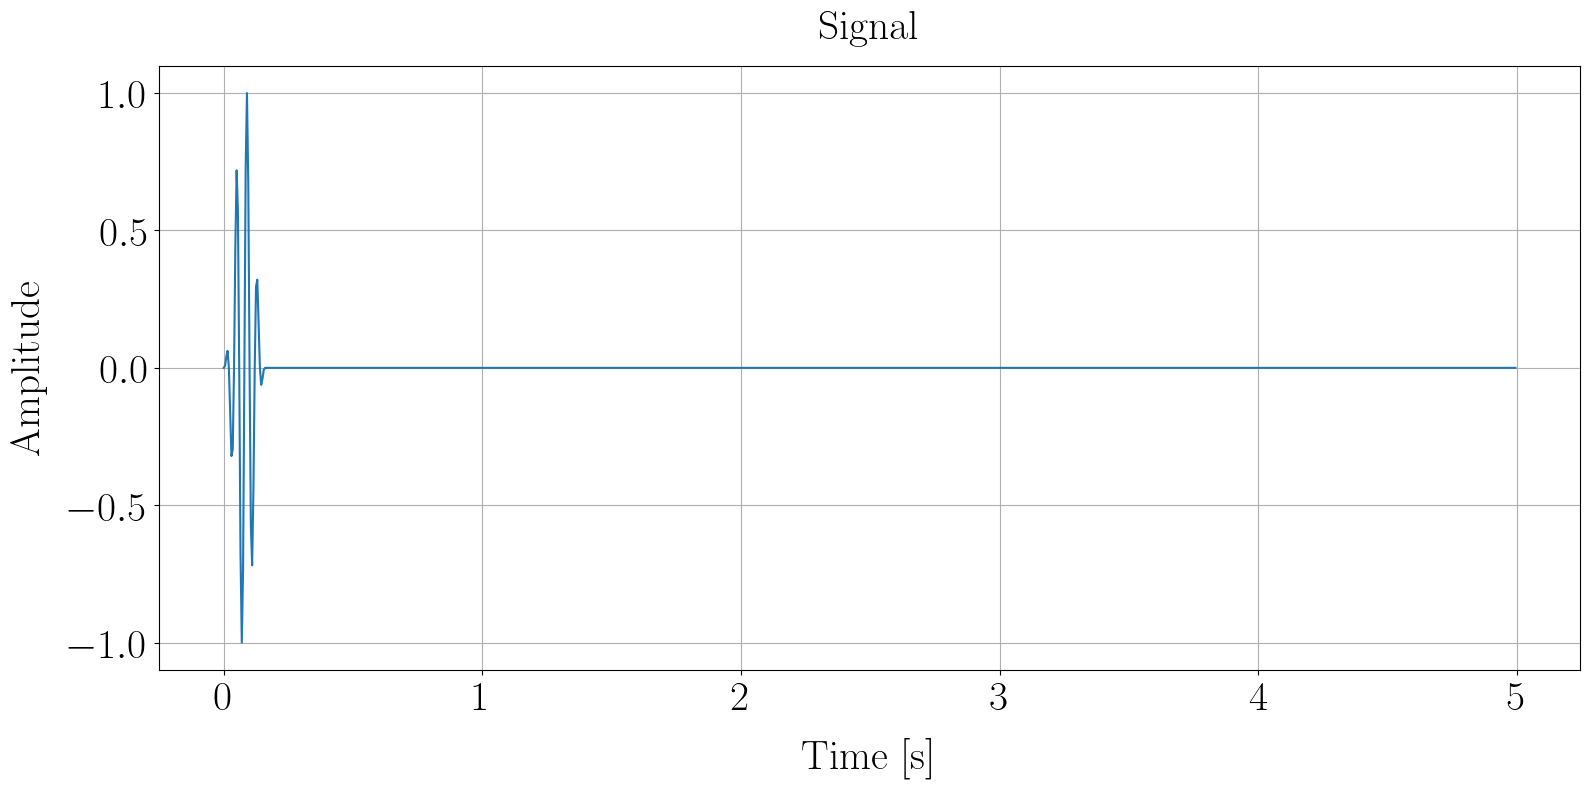

In [6]:
src_depth = z_s # m
src_min_freq = 0 # Hz
src_max_freq = fmax # Hz
src_fs = fs  # Hz

# Number of freq samples
# Time vector
df = freq[1] - freq[0]
nt = int(fs / df)
T = nt * 1 / fs
src_signal_duration = T  # s

# Create dummy signal to make it easy to run kraken simulation
fc = 25
sg = SignalGenerator()
s, t = sg.pulse(T=src_signal_duration, fc=fc, fs=src_fs, t0=0)

s = sg.normalize_sig(s, normalize="max")
# Plot time serie
sg.plot_signal(t, s)

src = AcousticSource(
    signal=s,
    time=t,
    name="Pulse",
    waveguide_depth=depth,
    window=None,
    nfft=2 ** int(np.log2(s.size) + 1),
)

## Définition du cas test avant calcul Kraken

In [7]:
# # env = KrakenEnv(
# #     title="Case 2 - Pekeris waveguide (range-independent, broadband)",
# #     env_root=HERE,
# #     env_filename=ENV_FILENAME,
# #     freq=FREQS,  # an array -> broadband_run is enabled automatically
# #     kraken_medium=medium,
# #     kraken_bottom_hs=bottom_hs,
# #     kraken_field=field,
# #     nmedia=None,
# # )
# # assert env.nmedia == 1
# # assert env.broadband_run
# # env.write_env()
# # print(f"Wrote {env.env_fpath} (nmedia={env.nmedia}, {env.freq.size} frequencies)")

# flp = KrakenFlp(
#     env=env,
#     src_type="point_source",
#     mode_theory="adiabatic",
#     mode_addition="coherent",
#     nb_modes=9999,
#     src_depth=SRC_DEPTH,
#     n_rcv_z=201,
#     rcv_z_min=0.0,
#     rcv_z_max=WATER_DEPTH,
#     n_rcv_r=501,
#     rcv_r_min=0.0,
#     rcv_r_max=5.0,
# )
# flp.write_flp()
# print(f"Wrote {flp.flp_fpath}")

# # ----------------------------------------------------------------------
# # 2. Run KRAKEN + FIELD
# # ----------------------------------------------------------------------
# if RUN_KRAKEN:
#     manager = KrakenManager(verbose=True)
#     manager.runkraken(env=env, flp=flp, frequencies=env.freq)
#     print("KRAKEN/FIELD run completed.")

In [ ]:
name = "test_nmedia_2"
title = "Test nmedia 2"

# Common properties
zmin = 0
zmax = depth
rmin = 0
rmax = max_range_km * 1e3

min_phase_speed = 1000
max_phase_speed = 20000

bott_props = {
    "rho": rho_sediment * 1e-3,  # Density (g/cm^3)
    "c_p": c_sediment,  # P-wave celerity (m/s)
    "c_s": 0.0,  # S-wave celerity (m/s)
    "a_p": alpha_sediment,  # Compression wave attenuation (dB/wavelength)
    "a_s": 0.0,  # Shear wave attenuation (dB/wavelength)
}

# Set domain properties
domain_properties = DomainProperties(zmin=zmin, zmax=zmax, rmin=0, rmax=rmax, unit="m")

# Set source properties
src_properties = SourceProperties(
    src_type="point_source", src_depth=src_depth, freq=src.kraken_freq
)
# Set receiver properties : needs to cover the whole water domain
rcv_z_min = zmin
rcv_z_max = zmax

# Number of receiver depths / ranges (flp file) : sufficient resolution for later use (can be easily downsampled afterwards)
dr = 50
dz = 5
nr_flp = int(rmax / dr) + 1
nz_flp = int(rcv_z_max / dz) + 1

rcv_properties = ReceiverProperties(
    zmin=rcv_z_min, zmax=rcv_z_max, rmin=rmin, rmax=rmax, unit="m"
)

# Set kraken properties
nmedia = 2

top_hs = KrakenTopHalfspace(
    boundary_condition="vacuum",
    halfspace_properties=None,
    twersky_scatter_properties=None,
)

bott_hs = KrakenBottomHalfspace(
    boundary_condition="acousto_elastic",
    halfspace_properties=bott_props,
    add_sediment_buffer_layer=True,  # needed to have a sediment layer at all
    fmin=100.0,  # sizes the sediment layer thickness (10 wavelengths at 100 Hz)
    alpha_wavelength=10,
)

# Set attenuation properties
att = KrakenAttenuation(units="dB_per_wavelength", use_volume_attenuation=False)
# Set SSP profile
z = [0, zmax]
c = [c_water, c_water]  # Constant celerity profile
ssp = SSPProfile(z=z, c=c)

# Create the medium = water column layer
medium = KrakenMedium(
    ssp_interpolation_method="C_linear",
    z_ssp=ssp.z,
    c_p=ssp.c,
    c_s=0.0,
    rho=1.0,
    a_p=0.0,
    a_s=0.0,
    nmesh=0,
    sigma=0.0,
)

n_rcv_z = default_nb_rcv_z(fmax=src.kraken_freq.max(), max_depth=depth, n_per_l=10)
field = KrakenField(
    phase_speed_limits=[min_phase_speed, max_phase_speed],
    src_depth=[src_properties.depth],
    n_rcv_z=n_rcv_z,
    rcv_z_min=0.0,
    rcv_z_max=depth,
    rcv_r_max=5.0,
)


kraken_properties = KrakenProperties(
    mode_coupling="coupled",
    mode_addition="coherent",
    n_mode=100,
    nr=nr_flp,
    nz=nz_flp,
    nmedia=nmedia,
    top_hs=top_hs,
    bott_hs=bott_hs,
    att=att,
    medium=medium,
    field=field,
)


k_tc = KrakenTestCase(
    name=name,
    title=title,
    root_dir=tc_root_dir,
    domain_properties=domain_properties,
    src_properties=src_properties,
    rcv_properties=rcv_properties,
    kraken_properties=kraken_properties,
)

In [ ]:
k_tc.run()

In [ ]:
name = "test_nmedia_1"
title = "Test nmedia 1"

# Common properties
zmin = 0
zmax = depth
rmin = 0
rmax = max_range_km * 1e3

min_phase_speed = 1000
max_phase_speed = 20000

bott_props = {
    "rho": rho_sediment * 1e-3,  # Density (g/cm^3)
    "c_p": c_sediment,  # P-wave celerity (m/s)
    "c_s": 0.0,  # S-wave celerity (m/s)
    "a_p": alpha_sediment,  # Compression wave attenuation (dB/wavelength)
    "a_s": 0.0,  # Shear wave attenuation (dB/wavelength)
}

# Set domain properties
domain_properties = DomainProperties(zmin=zmin, zmax=zmax, rmin=0, rmax=rmax, unit="m")

# Set source properties
src_properties = SourceProperties(
    src_type="point_source", src_depth=src_depth, freq=src.kraken_freq
)
# Set receiver properties : needs to cover the whole water domain
rcv_z_min = zmin
rcv_z_max = zmax

# Number of receiver depths / ranges (flp file) : sufficient resolution for later use (can be easily downsampled afterwards)
dr = 50
dz = 5
nr_flp = int(rmax / dr) + 1
nz_flp = int(rcv_z_max / dz) + 1

rcv_properties = ReceiverProperties(
    zmin=rcv_z_min, zmax=rcv_z_max, rmin=rmin, rmax=rmax, unit="m"
)

# Set kraken properties
nmedia = 1

top_hs = KrakenTopHalfspace(
    boundary_condition="vacuum",
    halfspace_properties=None,
    twersky_scatter_properties=None,
)

bott_hs = KrakenBottomHalfspace(
    boundary_condition="acousto_elastic",
    halfspace_properties=bott_props,
    add_sediment_buffer_layer=False,  # needed to have a sediment layer at all
)

# Set attenuation properties
att = KrakenAttenuation(units="dB_per_wavelength", use_volume_attenuation=False)
# Set SSP profile
z = [0, zmax]
c = [c_water, c_water]  # Constant celerity profile
ssp = SSPProfile(z=z, c=c)

# Create the medium = water column layer
medium = KrakenMedium(
    ssp_interpolation_method="C_linear",
    z_ssp=ssp.z,
    c_p=ssp.c,
    c_s=0.0,
    rho=1.0,
    a_p=0.0,
    a_s=0.0,
    nmesh=0,
    sigma=0.0,
)

n_rcv_z = default_nb_rcv_z(fmax=src.kraken_freq.max(), max_depth=depth, n_per_l=10)
field = KrakenField(
    phase_speed_limits=[min_phase_speed, max_phase_speed],
    src_depth=[src_properties.depth],
    n_rcv_z=n_rcv_z,
    rcv_z_min=0.0,
    rcv_z_max=depth,
    rcv_r_max=5.0,
)


kraken_properties = KrakenProperties(
    mode_coupling="coupled",
    mode_addition="coherent",
    n_mode=100,
    nr=nr_flp,
    nz=nz_flp,
    nmedia=nmedia,
    top_hs=top_hs,
    bott_hs=bott_hs,
    att=att,
    medium=medium,
    field=field,
)


k_tc = KrakenTestCase(
    name=name,
    title=title,
    root_dir=tc_root_dir,
    domain_properties=domain_properties,
    src_properties=src_properties,
    rcv_properties=rcv_properties,
    kraken_properties=kraken_properties,
)

In [ ]:
k_tc.run()

In [17]:
name = "test_kraken_cpu_time"
title = "Test CPU time for sensibility study"

# Common properties
zmin = 0
zmax = depth
rmin = 0
rmax = max_range_km * 1e3

min_phase_speed = 1000
max_phase_speed = 20000

bott_props = {
    "rho": rho_sediment * 1e-3,  # Density (g/cm^3)
    "c_p": c_sediment,  # P-wave celerity (m/s)
    "c_s": 0.0,  # S-wave celerity (m/s)
    "a_p": alpha_sediment,  # Compression wave attenuation (dB/wavelength)
    "a_s": 0.0,  # Shear wave attenuation (dB/wavelength)
}

# Set domain properties
domain_properties = DomainProperties(zmin=zmin, zmax=zmax, rmin=0, rmax=rmax, unit="m")

# Set source properties
src_properties = SourceProperties(
    src_type="point_source", src_depth=src_depth, freq=src.kraken_freq
)
# Set receiver properties : needs to cover the whole water domain
rcv_z_min = zmin
rcv_z_max = zmax

# Number of receiver depths / ranges (flp file) : sufficient resolution for later use (can be easily downsampled afterwards)
dr = 50
dz = 5
nr_flp = int(rmax / dr) + 1
nz_flp = int(rcv_z_max / dz) + 1

rcv_properties = ReceiverProperties(
    zmin=rcv_z_min, zmax=rcv_z_max, rmin=rmin, rmax=rmax, unit="m"
)

# Set kraken properties
nmedia = 2

top_hs = KrakenTopHalfspace(
    boundary_condition="vacuum",
    halfspace_properties=None,
    twersky_scatter_properties=None,
)

# bott_hs = KrakenBottomHalfspace(
#     boundary_condition="acousto_elastic",
#     halfspace_properties=bott_props,
#     add_sediment_buffer_layer=False,
# )

bott_hs = KrakenBottomHalfspace(
    boundary_condition="acousto_elastic",
    sigma=0.0,
    halfspace_properties=bott_props,
    fmin=src.kraken_freq.min(),
    alpha_wavelength=0.1,
    add_sediment_buffer_layer=True
)

# Set attenuation properties
att = KrakenAttenuation(units="dB_per_wavelength", use_volume_attenuation=False)
# Set SSP profile
z = [0, zmax]
c = [c_water, c_water]  # Constant celerity profile
ssp = SSPProfile(z=z, c=c)

# Create the medium = water column layer
medium = KrakenMedium(
    ssp_interpolation_method="C_linear",
    z_ssp=ssp.z,
    c_p=ssp.c,
    c_s=0.0,
    rho=1.0,
    a_p=0.0,
    a_s=0.0,
    nmesh=0,
    sigma=0.0,
)


# bott_hs.derive_sedim_layer_max_depth(domain_properties.zmax_m)
# max_rcv_depth = bott_hs.sedim_layer_max_depth
# n_rcv_z = default_nb_rcv_z(
#     fmax=src.kraken_freq.max(), max_depth=max_rcv_depth, n_per_l=10
# )
# field = KrakenField(
#     phase_speed_limits=[min_phase_speed, max_phase_speed],
#     src_depth=[src_properties.depth],
#     n_rcv_z=n_rcv_z,
#     rcv_z_min=0,
#     rcv_z_max=max_rcv_depth,
#     rcv_r_max=0.0,
# )

n_rcv_z = default_nb_rcv_z(
    fmax=src.kraken_freq.max(), max_depth=depth, n_per_l=10
)
field = KrakenField(
    phase_speed_limits=[min_phase_speed, max_phase_speed],
    src_depth=[src_properties.depth],
    n_rcv_z=n_rcv_z,
    rcv_z_min=0.0,
    rcv_z_max=depth,
    rcv_r_max=5.0,
)


kraken_properties = KrakenProperties(
    mode_coupling="coupled",
    mode_addition="coherent",
    n_mode=100,
    nr=nr_flp,
    nz=nz_flp,
    nmedia=nmedia,
    top_hs=top_hs,
    bott_hs=bott_hs,
    att=att,
    medium=medium,
    field=field,
)


k_tc = KrakenTestCase(
    name=name,
    title=title,
    root_dir=tc_root_dir,
    domain_properties=domain_properties,
    src_properties=src_properties,
    rcv_properties=rcv_properties,
    kraken_properties=kraken_properties,
)

In [ ]:
# k_tc.run()

In [ ]:
# k_tc.plot_diags()

In [ ]:
# from propa.kraken_toolbox.plot_utils import plotshd
# fpath = os.path.join(k_tc.io_files_dir, k_tc.env.filename)
# plotshd(
#     fpath + ".shd",
#     # title=f"{k_tc.name} - f={k_tc.src.freq}Hz",
#     bathy=k_tc.bathy,
#     # tl_min=tl_min,
#     # tl_max=tl_max,
#     freq=99
# )

## Calcul Kraken 

In [18]:
km = KrakenManager()
n_cpu_test = 1


i_test = 0
prev_progress = 0

# Iterate
t0 = time()
for i in range(n_cpu_test):
    i_test = i + 1
    prev_progress = progression_bar(
        index=i_test,
        index0=0,
        indexf=n_cpu_test,
        prev_progress=prev_progress,
    )

    pressure_field, field_pos = km.runkraken(
        env=k_tc.env, flp=k_tc.flp, frequencies=k_tc.src.freq
    )

cpu_tot_kraken = time() - t0

Progress: ████████████████████████████████████████████████████████████████████████████████████████████████████ 100%

In [ ]:
# (n_freq, Ntheta, Nsz, Nrcvrs_per_range, Nrr)
pressure_field.shape

In [ ]:
tl_fzr = -20 * np.log10(np.squeeze(np.abs(pressure_field)))
tl_zr = tl_fzr[200, 1:, ...]
im = plt.pcolormesh(tl_zr, cmap="jet")
plt.colorbar(im)

In [ ]:
# dr = r_grid[1] - r_grid[0]
# r_grid_add = np.arange(r_grid[-1] + dr, r_grid[-1] + dr + d12, dr)
# r_grid_ = np.append(r_grid, r_grid_add)

r_grid_ = field_pos["r"]["r"]
# print(r_grid_)

In [ ]:
i_test = 0
prev_progress = 0

t0 = time()
# Iterate
for i in range(n_cpu_test):
    i_test = i + 1
    prev_progress = progression_bar(
        index=i_test,
        index0=0,
        indexf=n_cpu_test,
        prev_progress=prev_progress,
    )

    g_fr = pekeris_green_fct(freq, c_w, c_s, rho_w, rho_s, d, z_s, z_rcv, r_grid_)

cpu_tot_analytic = time() - t0

In [ ]:
cpu_mean_kraken = cpu_tot_kraken / n_cpu_test
cpu_mean_analytic = cpu_tot_analytic / n_cpu_test

print(f"Kraken CPU time = {cpu_mean_kraken} s / env ({n_cpu_test} iterations)")
print(f"Analytic CPU time = {cpu_mean_analytic} s / env ({n_cpu_test} iterations)")